# Pit Stop Submission Blender

This notebook builds a compact blending workspace for the F1 pit stop prediction competition. It collects our own submissions and strong external submissions, normalizes them into a small dataset-like folder structure, compares prediction behavior, and creates several blend candidates without retraining any model.

The main idea is to use the high-scoring public submission cluster as a strong anchor, then test controlled additions from our CatBoost ensemble and from more diverse public submissions. The notebook keeps output names short and stores generated files under `outputs/blender/` so experiments stay easy to compare.


In [1]:
"""Import libraries, define paths, and create small display helpers."""

from pathlib import Path
from html import escape
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None
from IPython.display import display, HTML

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")
if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")
else:
    plt.style.use("ggplot")

TARGET_COL = "PitNextLap"
ID_COL = "id"
CLIP_LOW = 1e-7
CLIP_HIGH = 1 - 1e-7

INPUT_ROOTS = [
    Path("outputs"),
    Path("inputs"),
    Path("/kaggle/input"),
    Path("/Users/flexonafft/Downloads/archive"),
]

OUTPUT_ROOT = Path("outputs") / "blender"
DATASET_DIR = OUTPUT_ROOT / "dataset"
SUBMISSION_DIR = OUTPUT_ROOT / "subs"
REPORT_DIR = OUTPUT_ROOT / "reports"
for folder in [DATASET_DIR / "ours", DATASET_DIR / "public", DATASET_DIR / "other", SUBMISSION_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)


def fmt_value(value):
    if pd.isna(value):
        return "-"
    if isinstance(value, (np.integer, int)):
        return f"{int(value):,}"
    if isinstance(value, (np.floating, float)):
        if abs(value) >= 1000:
            return f"{value:,.0f}"
        return f"{value:.6f}".rstrip("0").rstrip(".")
    return str(value)


def show_title(title, subtitle=None):
    subtitle_html = f'<div style="color:#6b7280;font-size:13px;margin-top:3px;">{escape(str(subtitle))}</div>' if subtitle else ""
    display(HTML(
        f"""
        <div style="margin:18px 0 10px 0;padding-bottom:8px;border-bottom:1px solid #e5e7eb;">
          <div style="font-size:18px;font-weight:700;color:#111827;">{escape(str(title))}</div>
          {subtitle_html}
        </div>
        """
    ))


def show_metric_cards(title, data, columns=4):
    if isinstance(data, pd.DataFrame):
        data = data.iloc[0].to_dict() if len(data) else {}
    cards = []
    for key, value in data.items():
        cards.append(
            f"""
            <div style="border:1px solid #e5e7eb;border-radius:8px;padding:10px 12px;background:#ffffff;">
              <div style="font-size:11px;text-transform:uppercase;letter-spacing:.04em;color:#6b7280;">{escape(str(key).replace('_', ' '))}</div>
              <div style="font-size:18px;font-weight:700;color:#111827;margin-top:4px;">{escape(fmt_value(value))}</div>
            </div>
            """
        )
    display(HTML(
        f"""
        <div style="margin:12px 0;">
          <div style="font-size:15px;font-weight:700;color:#111827;margin-bottom:8px;">{escape(str(title))}</div>
          <div style="display:grid;grid-template-columns:repeat({columns},minmax(0,1fr));gap:8px;">
            {''.join(cards)}
          </div>
        </div>
        """
    ))




def show_fine_search_table(title, df):
    rows = []
    for _, row in df.iterrows():
        rows.append(
            f"""
            <tr>
              <td><strong>{escape(str(row['key']))}</strong></td>
              <td><code>{escape(str(row['file']))}</code></td>
              <td>{escape(str(row['type']))}</td>
              <td class="recipe">{escape(str(row['recipe']))}</td>
              <td>{escape(fmt_value(row['corr_b10']))}</td>
              <td>{escape(fmt_value(row['mean_abs_delta_b10']))}</td>
              <td>{escape(fmt_value(row['mean_abs_delta_core']))}</td>
            </tr>
            """
        )
    display(HTML(
        f"""
        <div style="margin:12px 0;max-width:1180px;">
          <div style="font-size:15px;font-weight:700;color:#111827;margin-bottom:8px;">{escape(str(title))}</div>
          <table class="fine-table">
            <thead>
              <tr>
                <th>Key</th>
                <th>File</th>
                <th>Type</th>
                <th>Recipe</th>
                <th>Corr b10</th>
                <th>Delta b10</th>
                <th>Delta core</th>
              </tr>
            </thead>
            <tbody>{''.join(rows)}</tbody>
          </table>
        </div>
        <style>
          table.fine-table {{border-collapse:collapse;width:100%;font-size:13px;table-layout:fixed;}}
          table.fine-table th {{background:#f9fafb;text-align:left;border-bottom:1px solid #e5e7eb;padding:8px;color:#374151;}}
          table.fine-table td {{border-bottom:1px solid #eef2f7;padding:8px;color:#111827;vertical-align:top;}}
          table.fine-table th:nth-child(1), table.fine-table td:nth-child(1) {{width:54px;}}
          table.fine-table th:nth-child(2), table.fine-table td:nth-child(2) {{width:82px;}}
          table.fine-table th:nth-child(3), table.fine-table td:nth-child(3) {{width:110px;}}
          table.fine-table th:nth-child(4), table.fine-table td:nth-child(4) {{width:auto;}}
          table.fine-table th:nth-child(5), table.fine-table td:nth-child(5),
          table.fine-table th:nth-child(6), table.fine-table td:nth-child(6),
          table.fine-table th:nth-child(7), table.fine-table td:nth-child(7) {{width:92px;text-align:right;}}
          table.fine-table td.recipe {{white-space:normal;line-height:1.35;word-break:break-word;}}
        </style>
        """
    ))


def show_records(title, df, max_rows=12):
    if len(df) > max_rows:
        df = df.head(max_rows).copy()
    display(HTML(
        f"""
        <div style="margin:12px 0;">
          <div style="font-size:15px;font-weight:700;color:#111827;margin-bottom:8px;">{escape(str(title))}</div>
          {df.to_html(index=False, escape=False, classes='compact-table')}
        </div>
        <style>
          table.compact-table {{border-collapse:collapse;width:100%;font-size:13px;}}
          table.compact-table th {{background:#f9fafb;text-align:left;border-bottom:1px solid #e5e7eb;padding:7px;color:#374151;}}
          table.compact-table td {{border-bottom:1px solid #eef2f7;padding:7px;color:#111827;}}
        </style>
        """
    ))


## 1. Build A Small Submission Dataset

The loader scans common local and Kaggle input folders, accepts only valid two-column submission files, and writes normalized copies into grouped folders: `ours`, `public`, and `other`. Public files named like `0.95405.csv` keep their score as metadata.


In [2]:
"""Find valid submission CSV files and organize them by source."""

score_pattern = re.compile(r"^0\.\d+$")


def infer_source(path):
    path_text = str(path).lower()
    stem = path.stem.lower()
    if score_pattern.match(stem) or "ps-s6e5-03" in path_text or "archive" in path_text:
        return "public"
    if "ensemblenote" in path_text or "f1-best" in path_text or "outputs/blends" in path_text or stem in {"prob", "rank", "s42", "s777"}:
        return "ours"
    if stem.startswith("submission_seed") or stem.startswith("submission_prob") or stem.startswith("submission_rank"):
        return "ours"
    return "other"


def public_score_from_name(path):
    return float(path.stem) if score_pattern.match(path.stem) else np.nan


def valid_submission_frame(path):
    try:
        head = pd.read_csv(path, nrows=5)
    except Exception:
        return None, None
    if ID_COL not in head.columns:
        return None, None

    target_col = None
    if TARGET_COL in head.columns:
        target_col = TARGET_COL
    else:
        non_id_cols = [col for col in head.columns if col != ID_COL]
        if len(non_id_cols) == 1:
            target_col = non_id_cols[0]

    if target_col is None or len(head.columns) > 3:
        return None, None

    try:
        df = pd.read_csv(path, usecols=[ID_COL, target_col])
    except Exception:
        return None, None

    if df.empty or df[ID_COL].duplicated().any():
        return None, None
    df = df.rename(columns={target_col: TARGET_COL})
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
    if df[TARGET_COL].isna().any():
        return None, None
    return df, target_col


candidate_paths = []
for root in INPUT_ROOTS:
    if root.exists():
        candidate_paths.extend(sorted(root.rglob("*.csv")))

records = []
submissions = {}
base_ids = None
seen_keys = set()

for path in candidate_paths:
    if OUTPUT_ROOT in path.parents:
        continue
    df, original_target = valid_submission_frame(path)
    if df is None:
        continue

    if base_ids is None:
        base_ids = df[ID_COL].copy()
    elif not base_ids.equals(df[ID_COL]):
        continue

    source = infer_source(path)
    score = public_score_from_name(path)
    raw_name = path.stem
    key_base = f"{source}_{raw_name}".replace(".", "_").replace("-", "_")
    key = key_base
    suffix = 2
    while key in seen_keys:
        key = f"{key_base}_{suffix}"
        suffix += 1
    seen_keys.add(key)

    pred = np.clip(df[TARGET_COL].to_numpy(dtype=float), CLIP_LOW, CLIP_HIGH)
    submissions[key] = pred

    organized_folder = DATASET_DIR / source
    organized_file = organized_folder / f"{key}.csv"
    pd.DataFrame({ID_COL: df[ID_COL].values, TARGET_COL: pred}).to_csv(organized_file, index=False)

    records.append(
        {
            "name": key,
            "source": source,
            "public_score": score,
            "rows": len(df),
            "mean": pred.mean(),
            "std": pred.std(),
            "file": organized_file.name,
            "original_path": str(path),
        }
    )

if not records:
    raise FileNotFoundError("No valid submission CSV files were found. Add our notebook output and/or the public blend dataset as inputs.")

submission_meta = pd.DataFrame(records).sort_values(["source", "public_score", "name"], ascending=[True, False, True]).reset_index(drop=True)
prediction_df = pd.DataFrame(submissions)
prediction_df.insert(0, ID_COL, base_ids.values)

submission_meta.to_csv(REPORT_DIR / "input_files.csv", index=False)
prediction_df.to_csv(REPORT_DIR / "prediction_matrix.csv", index=False)

show_title("Submission dataset", "Valid files were normalized and copied into grouped folders")
show_metric_cards(
    "Loaded files",
    {
        "total": len(submission_meta),
        "public": int((submission_meta["source"] == "public").sum()),
        "ours": int((submission_meta["source"] == "ours").sum()),
        "rows": len(prediction_df),
    },
    columns=4,
)
show_records("Top loaded submissions", submission_meta[["name", "source", "public_score", "rows", "mean", "std", "file"]].round(6), max_rows=18)


name,source,public_score,rows,mean,std,file
other_sample_submission,other,NaN,188165,0.000000,0.000000,other_sample_submission.csv
ours_p30r70,ours,NaN,188165,0.433061,0.301790,ours_p30r70.csv
ours_p50r50,ours,NaN,188165,0.388434,0.315286,ours_p50r50.csv
ours_p70r30,ours,NaN,188165,0.343808,0.331976,ours_p70r30.csv
ours_prob,ours,NaN,188165,0.276541,0.362038,ours_prob.csv
ours_prob_2,ours,NaN,188165,0.276869,0.362013,ours_prob_2.csv
ours_rank,ours,NaN,188165,0.500000,0.288489,ours_rank.csv
ours_s42,ours,NaN,188165,0.276623,0.362434,ours_s42.csv
ours_s42_2,ours,NaN,188165,0.276799,0.362418,ours_s42_2.csv
ours_s777,ours,NaN,188165,0.276787,0.361862,ours_s777.csv


## 2. Compare Prediction Behavior

Before blending, the notebook checks distribution shape, pairwise correlations, and how far each file moves from the strongest public anchor. This helps avoid blind averaging of nearly identical files.


name,source,public_score,corr_anchor,mean_abs_delta_anchor,p95_abs_delta_anchor,mean,std
other_sample_submission,other,NaN,0.000000,0.219467,0.902855,0.000000,0.000000
ours_prob,ours,NaN,0.981753,0.057743,0.230899,0.276541,0.362038
ours_t3407,ours,NaN,0.981553,0.058028,0.232075,0.276818,0.361968
ours_t123,ours,NaN,0.981532,0.058062,0.231881,0.276851,0.361975
ours_t2025,ours,NaN,0.981500,0.058133,0.232179,0.276924,0.362040
ours_prob_2,ours,NaN,0.981454,0.058099,0.232635,0.276869,0.362013
ours_sub,ours,NaN,0.981454,0.058099,0.232635,0.276869,0.362013
ours_submission,ours,NaN,0.981454,0.058099,0.232635,0.276869,0.362013
ours_s777,ours,NaN,0.981203,0.058101,0.232898,0.276787,0.361862
ours_s777_2,ours,NaN,0.981125,0.058246,0.233564,0.276939,0.361908


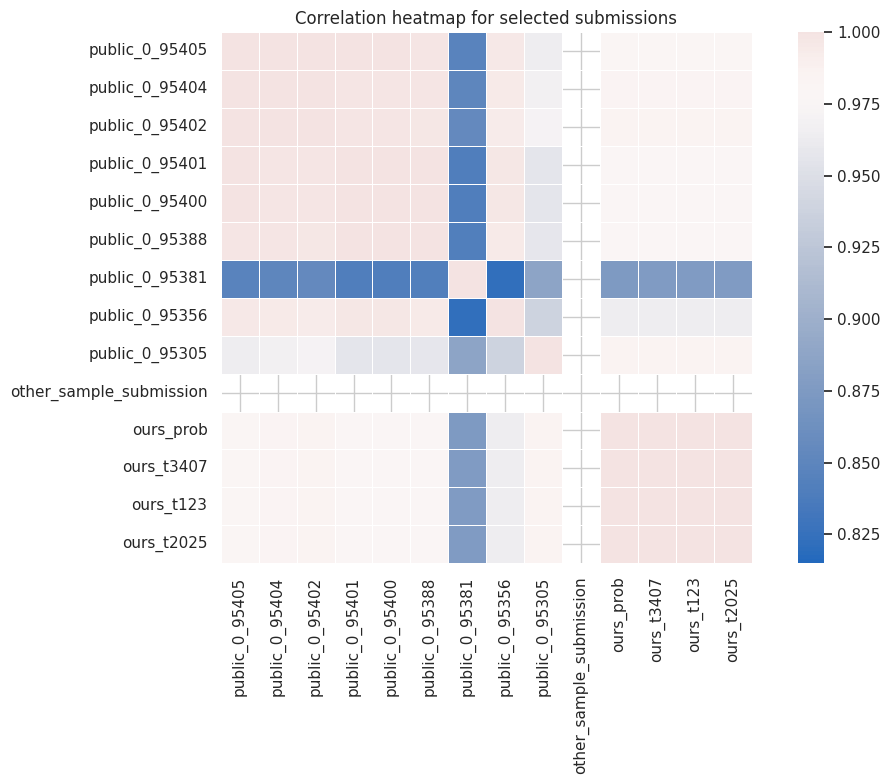

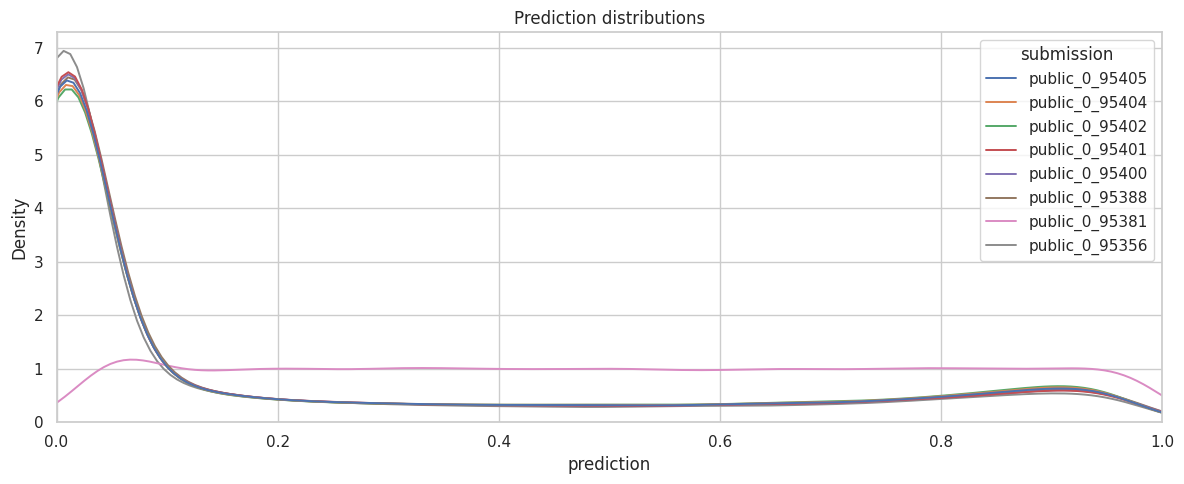

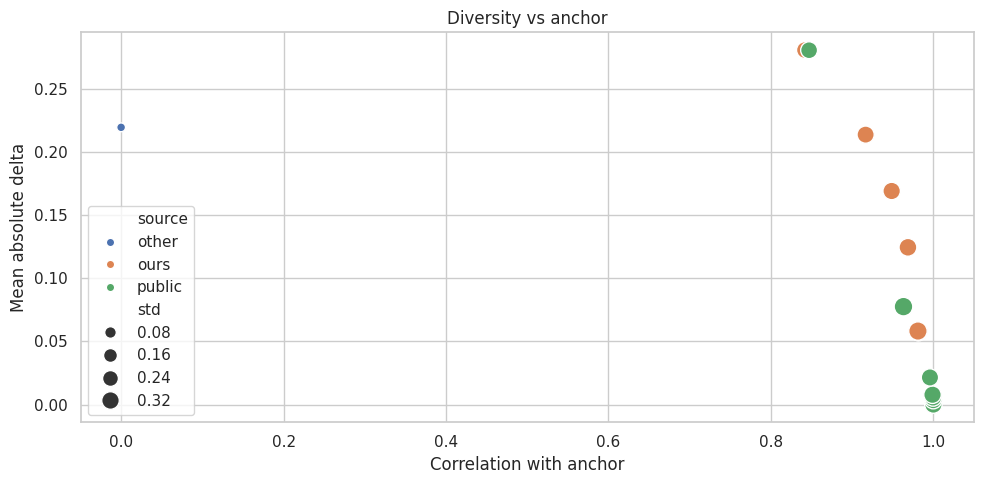

In [3]:
"""Compare distributions and correlations with seaborn visualizations."""

pred_cols = [col for col in prediction_df.columns if col != ID_COL]
corr = prediction_df[pred_cols].corr()
corr.to_csv(REPORT_DIR / "correlation.csv")

public_meta = submission_meta[submission_meta["source"] == "public"].dropna(subset=["public_score"]).copy()
if len(public_meta):
    anchor_name = public_meta.sort_values("public_score", ascending=False).iloc[0]["name"]
else:
    anchor_name = pred_cols[0]

comparison_rows = []
for name in pred_cols:
    pred = prediction_df[name].to_numpy(dtype=float)
    delta = pred - prediction_df[anchor_name].to_numpy(dtype=float)
    comparison_rows.append(
        {
            "name": name,
            "source": submission_meta.loc[submission_meta["name"] == name, "source"].iloc[0],
            "public_score": submission_meta.loc[submission_meta["name"] == name, "public_score"].iloc[0],
            "corr_anchor": np.corrcoef(pred, prediction_df[anchor_name].to_numpy(dtype=float))[0, 1],
            "mean_abs_delta_anchor": np.abs(delta).mean(),
            "p95_abs_delta_anchor": np.percentile(np.abs(delta), 95),
            "mean": pred.mean(),
            "std": pred.std(),
        }
    )
comparison = pd.DataFrame(comparison_rows).sort_values(["source", "public_score", "corr_anchor"], ascending=[True, False, False])
comparison.to_csv(REPORT_DIR / "submission_comparison.csv", index=False)

show_title("Prediction comparison", f"Anchor file: {anchor_name}")
show_records("Correlation and delta vs anchor", comparison.round(6), max_rows=18)

plot_order = comparison.sort_values("public_score", ascending=False).head(14)["name"].tolist()
if anchor_name not in plot_order:
    plot_order = [anchor_name] + plot_order[:13]

plt.figure(figsize=(11, 8))
if sns is not None:
    sns.heatmap(corr.loc[plot_order, plot_order], cmap="vlag", center=0.98, vmin=max(0.80, corr.min().min()), vmax=1.0, square=True, linewidths=0.4)
else:
    plt.imshow(corr.loc[plot_order, plot_order], vmin=max(0.80, corr.min().min()), vmax=1.0, cmap="coolwarm")
    plt.colorbar(label="correlation")
    plt.xticks(range(len(plot_order)), plot_order, rotation=90)
    plt.yticks(range(len(plot_order)), plot_order)
plt.title("Correlation heatmap for selected submissions")
plt.tight_layout()
plt.show()

sample_size = min(60000, len(prediction_df))
plot_sample = prediction_df[[ID_COL] + plot_order[:8]].sample(sample_size, random_state=42)
long_plot = plot_sample.melt(id_vars=ID_COL, var_name="submission", value_name="prediction")
plt.figure(figsize=(12, 5))
if sns is not None:
    sns.kdeplot(data=long_plot, x="prediction", hue="submission", common_norm=False, linewidth=1.4)
else:
    for name in plot_order[:8]:
        plt.hist(plot_sample[name], bins=80, histtype="step", density=True, label=name)
    plt.legend(fontsize=8)
plt.title("Prediction distributions")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
if sns is not None:
    sns.scatterplot(data=comparison, x="corr_anchor", y="mean_abs_delta_anchor", hue="source", size="std", sizes=(40, 180))
else:
    for source, part in comparison.groupby("source"):
        plt.scatter(part["corr_anchor"], part["mean_abs_delta_anchor"], label=source, alpha=0.8)
    plt.legend()
plt.title("Diversity vs anchor")
plt.xlabel("Correlation with anchor")
plt.ylabel("Mean absolute delta")
plt.tight_layout()
plt.show()


## 3. Create Blend Candidates

The notebook uses a few controlled techniques:

- **Public core mean:** average the strongest public cluster.
- **Rank mean:** blend rankings instead of raw probabilities.
- **Diversity injection:** add a small weight from predictions that differ from the public core.
- **Our CatBoost anchor:** add a controlled share of our own seed ensemble when available.
- **Cluster blend:** average inside groups first, then blend groups instead of all files equally.


In [4]:
"""Build several controlled blend candidates from public, diverse, and own submissions."""


def average_predictions(names):
    if not names:
        return None
    return np.clip(np.vstack([prediction_df[name].to_numpy(dtype=float) for name in names]).mean(axis=0), CLIP_LOW, CLIP_HIGH)


def normalize_0_1(values):
    values = np.asarray(values, dtype=float)
    return (values - values.min()) / (values.max() - values.min() + 1e-12)


def rank_average(names):
    if not names:
        return None
    ranks = np.vstack([normalize_0_1(pd.Series(prediction_df[name]).rank(method="average").to_numpy()) for name in names])
    return np.clip(ranks.mean(axis=0), CLIP_LOW, CLIP_HIGH)


public_scored = submission_meta[submission_meta["source"].eq("public") & submission_meta["public_score"].notna()].copy()
public_scored = public_scored.sort_values("public_score", ascending=False)
public_core_names = public_scored.head(6)["name"].tolist()

core_pred = average_predictions(public_core_names)
if core_pred is None:
    public_core_names = pred_cols[: min(6, len(pred_cols))]
    core_pred = average_predictions(public_core_names)

core_delta_rows = []
for name in pred_cols:
    if name in public_core_names:
        continue
    pred = prediction_df[name].to_numpy(dtype=float)
    core_delta_rows.append(
        {
            "name": name,
            "source": submission_meta.loc[submission_meta["name"] == name, "source"].iloc[0],
            "public_score": submission_meta.loc[submission_meta["name"] == name, "public_score"].iloc[0],
            "corr_core": np.corrcoef(pred, core_pred)[0, 1],
            "mean_abs_delta_core": np.abs(pred - core_pred).mean(),
        }
    )
if core_delta_rows:
    core_delta = pd.DataFrame(core_delta_rows).sort_values(["corr_core", "public_score"], ascending=[True, False])
else:
    core_delta = pd.DataFrame(columns=["name", "source", "public_score", "corr_core", "mean_abs_delta_core"])

public_diverse_names = core_delta[core_delta["source"].eq("public")].head(5)["name"].tolist()
ours_names = submission_meta[submission_meta["source"].eq("ours")]["name"].tolist()

if ours_names:
    preferred = [name for name in ours_names if any(token in name.lower() for token in ["prob", "pair", "s42", "s777"])]
    ours_anchor_names = preferred[:3] if preferred else ours_names[:3]
else:
    ours_anchor_names = []

public_diverse_pred = average_predictions(public_diverse_names)
ours_pred = average_predictions(ours_anchor_names)
rank_core_pred = rank_average(public_core_names)

blend_specs = []
blend_predictions = {}


def add_blend(key, pred, formula):
    if pred is None:
        return
    blend_predictions[key] = np.clip(pred, CLIP_LOW, CLIP_HIGH)
    blend_specs.append({"key": key, "formula": formula})


add_blend("b01", core_pred, "public_core_mean")
add_blend("b02", rank_core_pred, "rank_mean(public_core)")

if public_diverse_pred is not None:
    add_blend("b03", 0.90 * core_pred + 0.10 * public_diverse_pred, "0.90*public_core + 0.10*public_diverse")
    add_blend("b04", 0.85 * core_pred + 0.15 * public_diverse_pred, "0.85*public_core + 0.15*public_diverse")

if ours_pred is not None:
    add_blend("b05", 0.80 * core_pred + 0.20 * ours_pred, "0.80*public_core + 0.20*ours")
    add_blend("b06", 0.70 * core_pred + 0.30 * ours_pred, "0.70*public_core + 0.30*ours")
    add_blend("b07", rank_average(public_core_names + ours_anchor_names), "rank_mean(public_core + ours)")
    if public_diverse_pred is not None:
        add_blend("b08", 0.80 * core_pred + 0.15 * ours_pred + 0.05 * public_diverse_pred, "0.80*public_core + 0.15*ours + 0.05*public_diverse")
        add_blend("b09", 0.75 * core_pred + 0.20 * ours_pred + 0.05 * public_diverse_pred, "0.75*public_core + 0.20*ours + 0.05*public_diverse")

special_95381 = [name for name in pred_cols if "0_95381" in name or "0.95381" in name]
if special_95381:
    special_pred = prediction_df[special_95381[0]].to_numpy(dtype=float)
    add_blend("b10", 0.95 * core_pred + 0.05 * special_pred, "0.95*public_core + 0.05*0.95381")
    add_blend("b11", 0.90 * core_pred + 0.10 * special_pred, "0.90*public_core + 0.10*0.95381")

blend_setup = pd.DataFrame(
    [
        {"group": "public_core", "count": len(public_core_names), "members": ", ".join(public_core_names)},
        {"group": "public_diverse", "count": len(public_diverse_names), "members": ", ".join(public_diverse_names)},
        {"group": "ours_anchor", "count": len(ours_anchor_names), "members": ", ".join(ours_anchor_names)},
    ]
)
blend_setup.to_csv(REPORT_DIR / "blend_groups.csv", index=False)

show_title("Blend setup", "Groups are built from score strength and prediction diversity")
show_records("Blend groups", blend_setup, max_rows=5)
show_records("Diverse candidates vs public core", core_delta.round(6), max_rows=12)
show_metric_cards("Generated blends", {"blend_count": len(blend_predictions), "public_core_files": len(public_core_names), "ours_files": len(ours_anchor_names)}, columns=3)


group,count,members
public_core,6,"public_0_95405, public_0_95404, public_0_95402, public_0_95401, public_0_95400, public_0_95388"
public_diverse,3,"public_0_95381, public_0_95305, public_0_95356"
ours_anchor,3,"ours_prob, ours_prob_2, ours_s42"


name,source,public_score,corr_core,mean_abs_delta_core
other_sample_submission,other,NaN,-0.000000,0.218960
ours_rank,ours,NaN,0.841237,0.281149
public_0_95381,public,0.953810,0.846074,0.281043
ours_p30r70,ours,NaN,0.916008,0.214189
ours_p50r50,ours,NaN,0.948171,0.169559
public_0_95305,public,0.953050,0.962160,0.078164
ours_p70r30,ours,NaN,0.968285,0.124950
ours_s42_2,ours,NaN,0.980705,0.058558
ours_s777_2,ours,NaN,0.980850,0.058636
ours_s42,ours,NaN,0.980857,0.058370


## 4. Save And Inspect Blend Files

Blend files are saved with short names under `outputs/blender/subs/`. The root `submission.csv` is also written from `b01`, the safest public-core baseline, so Kaggle can find a default file immediately.


key,file,formula,mean,std,corr_core,corr_anchor,mean_abs_delta_core,p95_abs_delta_core
b01,b01.csv,public_core_mean,0.218960,0.315957,1.000000,0.999946,0.000000,0.000000
b03,b03.csv,0.90*public_core + 0.10*public_diverse,0.230215,0.314703,0.999764,0.999789,0.011261,0.022411
b05,b05.csv,0.80*public_core + 0.20*ours,0.230503,0.324133,0.999079,0.999096,0.011657,0.046646
b10,b10.csv,0.95*public_core + 0.05*0.95381,0.233012,0.312425,0.999699,0.999689,0.014052,0.026427
b08,b08.csv,0.80*public_core + 0.15*ours + 0.05*public_diverse,0.233245,0.321456,0.999205,0.999244,0.014301,0.043986
b04,b04.csv,0.85*public_core + 0.15*public_diverse,0.235843,0.314132,0.999468,0.999532,0.016891,0.033617
b09,b09.csv,0.75*public_core + 0.20*ours + 0.05*public_diverse,0.236131,0.323578,0.998741,0.998797,0.017198,0.055585
b06,b06.csv,0.70*public_core + 0.30*ours,0.236275,0.328437,0.997980,0.998032,0.017485,0.069970
b11,b11.csv,0.90*public_core + 0.10*0.95381,0.247064,0.309086,0.998768,0.998803,0.028104,0.052853
b02,b02.csv,rank_mean(public_core),0.500000,0.288529,0.844716,0.845562,0.281040,0.529737


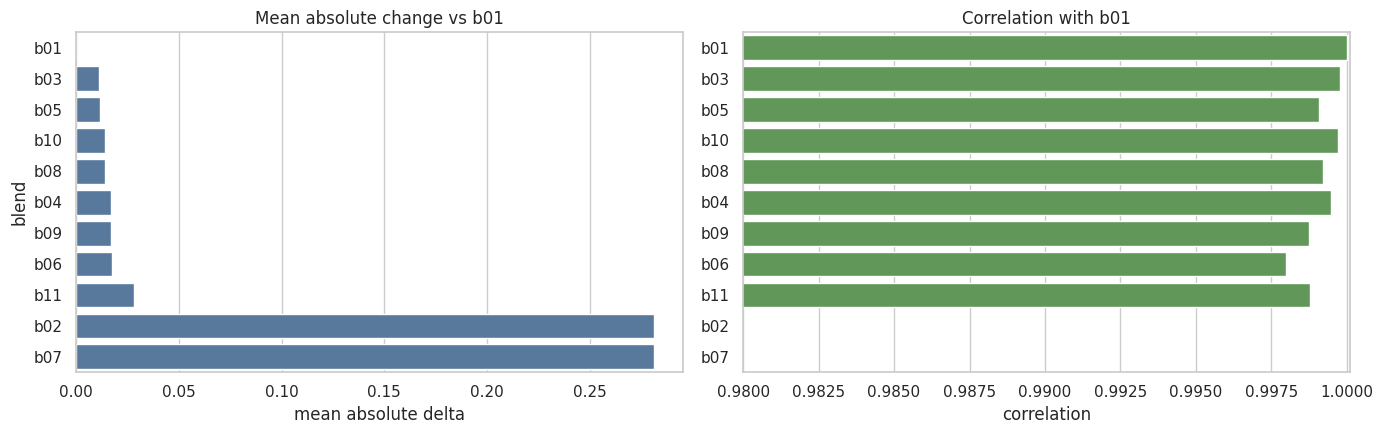

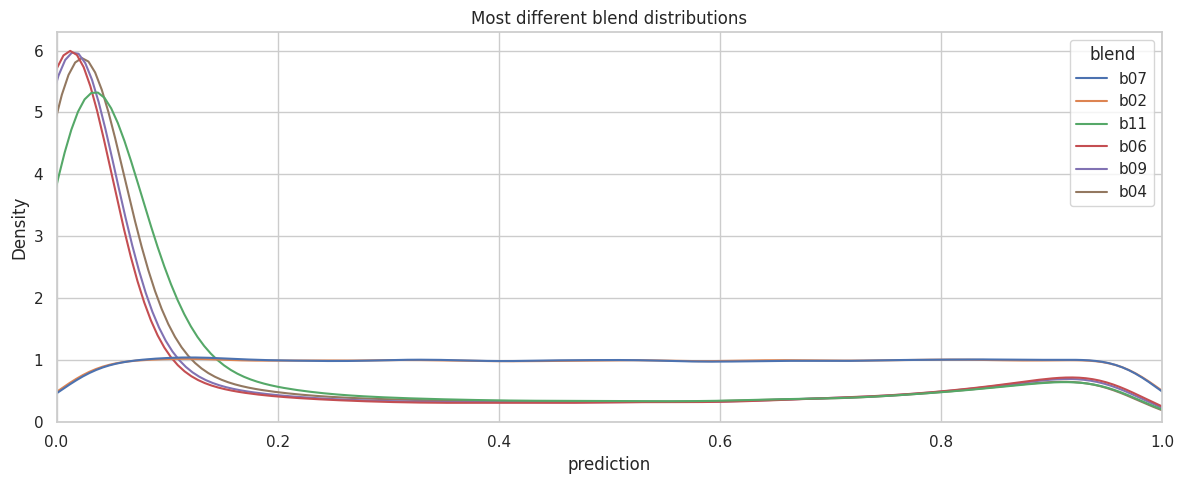

In [5]:
"""Save blend CSV files and compare their movement against the public core baseline."""


def save_submission(path, pred):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    sub = pd.DataFrame({ID_COL: base_ids.values, TARGET_COL: np.clip(pred, CLIP_LOW, CLIP_HIGH)})
    sub.to_csv(path, index=False)


core_baseline = blend_predictions["b01"]
anchor_pred = prediction_df[anchor_name].to_numpy(dtype=float)
summary_rows = []

for item in blend_specs:
    key = item["key"]
    pred = blend_predictions[key]
    filename = f"{key}.csv"
    save_submission(SUBMISSION_DIR / filename, pred)
    summary_rows.append(
        {
            "key": key,
            "file": filename,
            "formula": item["formula"],
            "mean": pred.mean(),
            "std": pred.std(),
            "corr_core": np.corrcoef(pred, core_baseline)[0, 1],
            "corr_anchor": np.corrcoef(pred, anchor_pred)[0, 1],
            "mean_abs_delta_core": np.abs(pred - core_baseline).mean(),
            "p95_abs_delta_core": np.percentile(np.abs(pred - core_baseline), 95),
        }
    )

blend_summary = pd.DataFrame(summary_rows).sort_values(["mean_abs_delta_core", "key"]).reset_index(drop=True)
blend_summary.to_csv(REPORT_DIR / "blend_summary.csv", index=False)
save_submission("submission.csv", blend_predictions["b01"])

show_title("Saved blend files", "Short names are used for quick Kaggle submissions")
show_records("Blend summary", blend_summary.round(6), max_rows=len(blend_summary))
show_metric_cards(
    "Default submission",
    {
        "source": "b01",
        "file": "submission.csv",
        "saved_blends": len(blend_summary),
        "folder": str(SUBMISSION_DIR),
    },
    columns=4,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
if sns is not None:
    sns.barplot(data=blend_summary, y="key", x="mean_abs_delta_core", ax=axes[0], color="#4c78a8")
else:
    axes[0].barh(blend_summary["key"], blend_summary["mean_abs_delta_core"], color="#4c78a8")
axes[0].set_title("Mean absolute change vs b01")
axes[0].set_xlabel("mean absolute delta")
axes[0].set_ylabel("blend")

if sns is not None:
    sns.barplot(data=blend_summary, y="key", x="corr_core", ax=axes[1], color="#59a14f")
else:
    axes[1].barh(blend_summary["key"], blend_summary["corr_core"], color="#59a14f")
axes[1].set_title("Correlation with b01")
axes[1].set_xlabel("correlation")
axes[1].set_ylabel("")
axes[1].set_xlim(max(0.98, blend_summary["corr_core"].min() - 0.001), 1.0001)
plt.tight_layout()
plt.show()

plot_keys = blend_summary.sort_values("mean_abs_delta_core", ascending=False).head(6)["key"].tolist()
plot_blends = pd.DataFrame({key: blend_predictions[key] for key in plot_keys})
plot_blends.insert(0, ID_COL, base_ids.values)
plot_sample = plot_blends.sample(min(60000, len(plot_blends)), random_state=42)
plot_long = plot_sample.melt(id_vars=ID_COL, var_name="blend", value_name="prediction")

plt.figure(figsize=(12, 5))
if sns is not None:
    sns.kdeplot(data=plot_long, x="prediction", hue="blend", common_norm=False, linewidth=1.5)
else:
    for key in plot_keys:
        plt.hist(plot_sample[key], bins=80, histtype="step", density=True, label=key)
    plt.legend(fontsize=8)
plt.title("Most different blend distributions")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


## 5. Fine Search Around b10

The first research run showed that `b10` was the strongest candidate: `0.95 * public_core + 0.05 * public_0.95381`. This is a useful signal because `public_core` is a very stable high-score cluster, while `0.95381` has a much lower correlation with that cluster and a different prediction distribution. A small weight from this diverse submission appears to correct some public-core mistakes without overwhelming the strong anchor.

The next step is deliberately narrow. Instead of changing the whole blender, this block searches around the successful `5%` weight: a few nearby weights for `0.95381`, plus tiny additions from our CatBoost probability mean and from `0.95305`. These candidates are saved separately so they can be tested without mixing them with the broader exploratory blends.


Key,File,Type,Recipe,Corr b10,Delta b10,Delta core
w050,w050.csv,95381 weight,0.950*core + 0.050*95381,1,0,0.014052
o005,o005.csv,add ours,0.945*core + 0.050*95381 + 0.005*ours_prob,0.999999,0.000291,0.01434
d005,d005.csv,add 95305,0.945*core + 0.050*95381 + 0.005*95305,0.999999,0.000391,0.014437
o010,o010.csv,add ours,0.940*core + 0.050*95381 + 0.010*ours_prob,0.999998,0.000581,0.014628
d010,d010.csv,add 95305,0.940*core + 0.050*95381 + 0.010*95305,0.999995,0.000782,0.014823
o015,o015.csv,add ours,0.935*core + 0.050*95381 + 0.015*ours_prob,0.999995,0.000872,0.014916
o020,o020.csv,add ours,0.930*core + 0.050*95381 + 0.020*ours_prob,0.99999,0.001163,0.015204
d015,d015.csv,add 95305,0.935*core + 0.050*95381 + 0.015*95305,0.999988,0.001172,0.015208
w055,w055.csv,95381 weight,0.945*core + 0.055*95381,0.999997,0.001405,0.015457
w045,w045.csv,95381 weight,0.955*core + 0.045*95381,0.999997,0.001405,0.012647


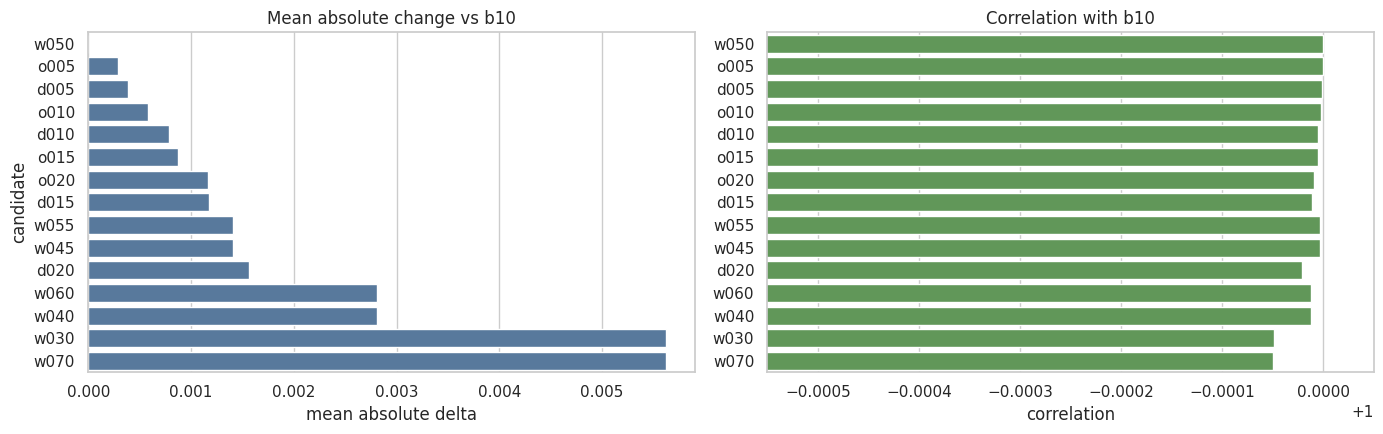

In [6]:
"""Create a narrow set of candidate blends around the successful b10 recipe."""

fine_output_dir = SUBMISSION_DIR / "fine_b10"
fine_output_dir.mkdir(parents=True, exist_ok=True)

if "b01" not in blend_predictions:
    raise RuntimeError("Run the base blend creation cell before fine searching around b10.")

def find_public_submission_by_score(score, atol=1e-8):
    matches = submission_meta[
        submission_meta["source"].eq("public")
        & np.isclose(submission_meta["public_score"].astype(float), score, atol=atol, equal_nan=False)
    ]["name"].tolist()
    if matches:
        return matches[0]

    score_token = f"{score:.5f}".replace(".", "_")
    fallback_matches = [name for name in pred_cols if score_token in name or f"{score:.5f}" in name]
    return fallback_matches[0] if fallback_matches else None


name_95381 = find_public_submission_by_score(0.95381)
name_95305 = find_public_submission_by_score(0.95305)
if name_95381 is None:
    available_public = submission_meta[submission_meta["source"].eq("public")][["name", "public_score"]].sort_values("public_score", ascending=False)
    raise RuntimeError(
        "The public 0.95381 submission is required for the b10 fine search. "
        f"Available public files: {available_public.to_dict('records')}"
    )

core_pred = blend_predictions["b01"]
diverse_95381_pred = prediction_df[name_95381].to_numpy(dtype=float)
ours_prob_names = [name for name in pred_cols if name in {"ours_prob", "ours_submission_prob_mean"}]
ours_prob_pred = prediction_df[ours_prob_names[0]].to_numpy(dtype=float) if ours_prob_names else ours_pred
support_95305_pred = prediction_df[name_95305].to_numpy(dtype=float) if name_95305 is not None else None

fine_specs = []

# Weight-only search around the proven 5% diverse-submission recipe.
for weight_95381 in [0.030, 0.040, 0.045, 0.050, 0.055, 0.060, 0.070]:
    fine_specs.append(
        {
            "key": f"w{int(weight_95381 * 1000):03d}",
            "formula": f"{1 - weight_95381:.3f}*public_core + {weight_95381:.3f}*0.95381",
            "weights": {"core": 1 - weight_95381, "p95381": weight_95381},
        }
    )

# Tiny additions from our CatBoost probability mean.
if ours_prob_pred is not None:
    for ours_weight in [0.005, 0.010, 0.015, 0.020]:
        fine_specs.append(
            {
                "key": f"o{int(ours_weight * 1000):03d}",
                "formula": f"{0.95 - ours_weight:.3f}*public_core + 0.050*0.95381 + {ours_weight:.3f}*ours_prob",
                "weights": {"core": 0.95 - ours_weight, "p95381": 0.050, "ours": ours_weight},
            }
        )

# Tiny additions from public 0.95305 as a second moderate-diversity source.
if support_95305_pred is not None:
    for support_weight in [0.005, 0.010, 0.015, 0.020]:
        fine_specs.append(
            {
                "key": f"d{int(support_weight * 1000):03d}",
                "formula": f"{0.95 - support_weight:.3f}*public_core + 0.050*0.95381 + {support_weight:.3f}*0.95305",
                "weights": {"core": 0.95 - support_weight, "p95381": 0.050, "p95305": support_weight},
            }
        )

fine_rows = []
fine_predictions = {}
for spec in fine_specs:
    weights = spec["weights"]
    pred = weights.get("core", 0.0) * core_pred + weights.get("p95381", 0.0) * diverse_95381_pred
    if "ours" in weights:
        pred += weights["ours"] * ours_prob_pred
    if "p95305" in weights:
        pred += weights["p95305"] * support_95305_pred
    pred = np.clip(pred, CLIP_LOW, CLIP_HIGH)
    fine_predictions[spec["key"]] = pred

    filename = f"{spec['key']}.csv"
    save_submission(fine_output_dir / filename, pred)
    fine_rows.append(
        {
            "key": spec["key"],
            "file": filename,
            "formula": spec["formula"],
            "mean": pred.mean(),
            "std": pred.std(),
            "corr_b10": np.corrcoef(pred, blend_predictions["b10"])[0, 1] if "b10" in blend_predictions else np.nan,
            "corr_core": np.corrcoef(pred, core_pred)[0, 1],
            "mean_abs_delta_b10": np.abs(pred - blend_predictions["b10"]).mean() if "b10" in blend_predictions else np.nan,
            "mean_abs_delta_core": np.abs(pred - core_pred).mean(),
            "p95_abs_delta_core": np.percentile(np.abs(pred - core_pred), 95),
        }
    )

fine_summary = pd.DataFrame(fine_rows).sort_values(["mean_abs_delta_b10", "key"]).reset_index(drop=True)
fine_summary.to_csv(REPORT_DIR / "fine_b10_summary.csv", index=False)

fine_display = fine_summary.copy()
fine_display["type"] = fine_display["key"].str[0].map(
    {
        "w": "95381 weight",
        "o": "add ours",
        "d": "add 95305",
    }
)
fine_display["recipe"] = fine_display["formula"].str.replace("public_core", "core", regex=False).str.replace("0.95381", "95381", regex=False).str.replace("0.95305", "95305", regex=False)
fine_display = fine_display[
    [
        "key",
        "file",
        "type",
        "recipe",
        "corr_b10",
        "mean_abs_delta_b10",
        "mean_abs_delta_core",
    ]
].round(6)

show_title("Fine search around b10", "Narrow candidates around the proven 0.95 core / 0.05 diverse blend")
show_fine_search_table("Files to try", fine_display)
show_metric_cards(
    "Fine search files",
    {
        "candidates": len(fine_summary),
        "folder": str(fine_output_dir),
        "baseline": "b10",
    },
    columns=3,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
if sns is not None:
    sns.barplot(data=fine_summary, y="key", x="mean_abs_delta_b10", ax=axes[0], color="#4c78a8")
else:
    axes[0].barh(fine_summary["key"], fine_summary["mean_abs_delta_b10"], color="#4c78a8")
axes[0].set_title("Mean absolute change vs b10")
axes[0].set_xlabel("mean absolute delta")
axes[0].set_ylabel("candidate")

if sns is not None:
    sns.barplot(data=fine_summary, y="key", x="corr_b10", ax=axes[1], color="#59a14f")
else:
    axes[1].barh(fine_summary["key"], fine_summary["corr_b10"], color="#59a14f")
axes[1].set_title("Correlation with b10")
axes[1].set_xlabel("correlation")
axes[1].set_ylabel("")
axes[1].set_xlim(max(0.995, fine_summary["corr_b10"].min() - 0.0005), 1.00005)
plt.tight_layout()
plt.show()
